# Exploratory Data Analysis (EDA)

## Credit Card Fraud Detection Dataset

**Objective:** Understand the data distribution, class imbalance, and feature patterns.

## 1. Setup and Imports

In [10]:
import sys
import os
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Visualization settings
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.6f}'.format)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Data from Database

In [11]:
# Connect to database
conn = psycopg2.connect(
    host=os.getenv('DB_HOST', 'localhost'),
    port=int(os.getenv('DB_PORT', 5432)),
    database=os.getenv('DB_NAME', 'fraud_detection'),
    user=os.getenv('DB_USER', 'postgres'),
    password=os.getenv('DB_PASSWORD', '')
)

# Load data into DataFrame
query = "SELECT * FROM transactions_raw"
df = pd.read_sql(query, conn)

conn.close()

print(f"✓ Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nDataset shape: {df.shape}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

C:\Users\Dell\AppData\Local\Temp\ipykernel_16380\1422926949.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


✓ Data loaded: 284,807 rows × 33 columns

Dataset shape: (284807, 33)

Memory usage: 71.71 MB


## 3. Basic Dataset Information

In [12]:
# Display basic info
print("=== Column Names ===")
print(df.columns.tolist())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df.describe())

=== Column Names ===
['id', 'time_elapsed', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount', 'class', 'ingested_at']

=== Data Types ===
id                       int64
time_elapsed           float64
v1                     float64
v2                     float64
v3                     float64
v4                     float64
v5                     float64
v6                     float64
v7                     float64
v8                     float64
v9                     float64
v10                    float64
v11                    float64
v12                    float64
v13                    float64
v14                    float64
v15                    float64
v16                    float64
v17                    float64
v18                    float64
v19                    float64
v20                    float64
v21                    float64
v2

## 4. Class Distribution (Target Variable)

In [13]:
# Class distribution
class_counts = df['class'].value_counts()
class_percentages = df['class'].value_counts(normalize=True) * 100

print("=== Class Distribution ===")
for label, count in class_counts.items():
    label_name = "Fraud" if label == 1 else "Legitimate"
    percentage = class_percentages[label]
    print(f"{label_name}: {count:,} ({percentage:.4f}%)")

print(f"\nImbalance Ratio: {class_counts[0] / class_counts[1]:.2f}:1")

=== Class Distribution ===
Legitimate: 284,315 (99.8273%)
Fraud: 492 (0.1727%)

Imbalance Ratio: 577.88:1


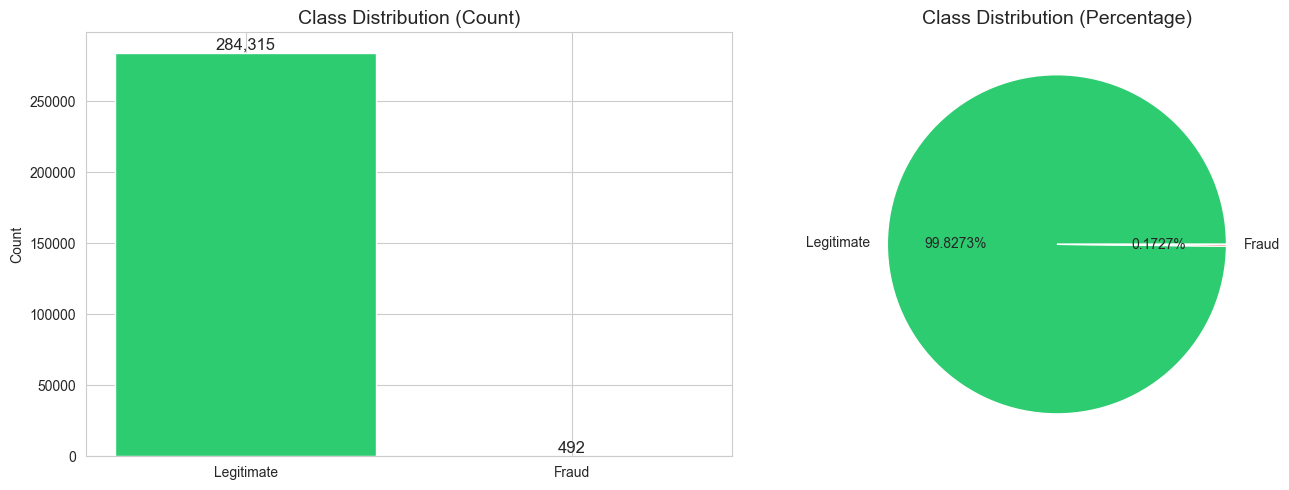

✓ Chart saved to docs/images/class_distribution.png


In [14]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Legitimate', 'Fraud'], class_counts.values, color=colors)
axes[0].set_title('Class Distribution (Count)', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=12)

# Pie chart
axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraud'], autopct='%1.4f%%', colors=colors)
axes[1].set_title('Class Distribution (Percentage)', fontsize=14)

plt.tight_layout()
plt.savefig('../docs/images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart saved to docs/images/class_distribution.png")

## 5. Transaction Amount Analysis

In [15]:
# Amount statistics by class
print("=== Amount Statistics ===")
print(df.groupby('class')['amount'].describe())

print("\n=== Amount by Class ===")
print(f"Legitimate transactions: ${df[df['class']==0]['amount'].mean():.2f} average")
print(f"Fraudulent transactions: ${df[df['class']==1]['amount'].mean():.2f} average")

=== Amount Statistics ===
              count       mean        std      min      25%       50%  \
class                                                                   
0     284315.000000  88.291022 250.105092 0.000000 5.650000 22.000000   
1        492.000000 122.211321 256.683288 0.000000 1.000000  9.250000   

             75%          max  
class                          
0      77.050000 25691.160000  
1     105.890000  2125.870000  

=== Amount by Class ===
Legitimate transactions: $88.29 average
Fraudulent transactions: $122.21 average


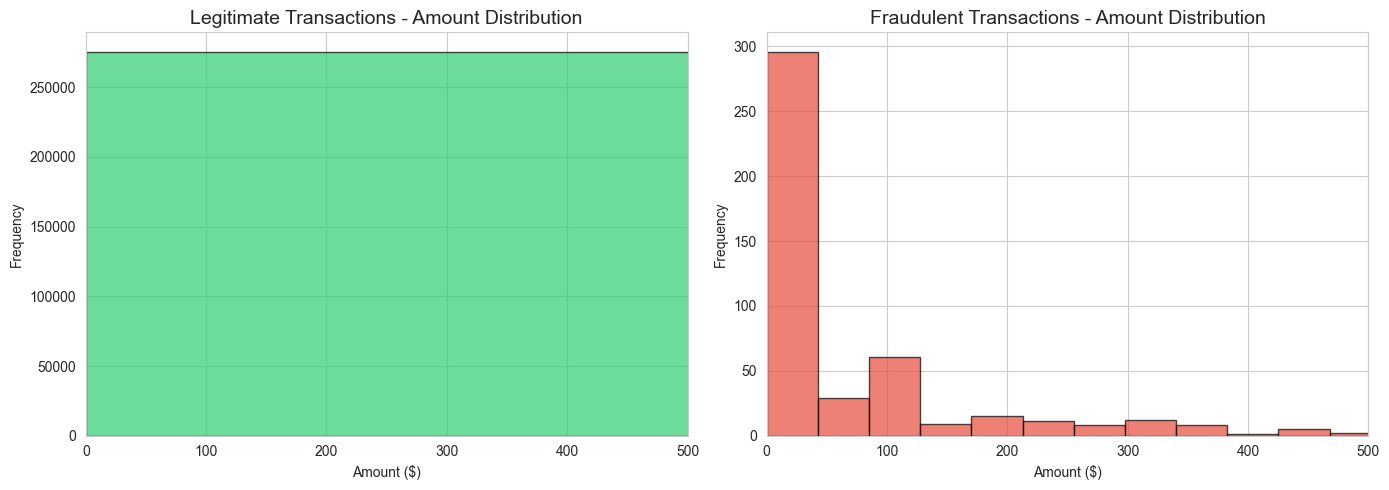

✓ Chart saved to docs/images/amount_distribution.png


In [16]:
# Visualize amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram - Legitimate
axes[0].hist(df[df['class']==0]['amount'], bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0].set_title('Legitimate Transactions - Amount Distribution', fontsize=14)
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 500)  # Limit for better visualization

# Histogram - Fraud
axes[1].hist(df[df['class']==1]['amount'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].set_title('Fraudulent Transactions - Amount Distribution', fontsize=14)
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.savefig('../docs/images/amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart saved to docs/images/amount_distribution.png")

## 6. Time Analysis

In [17]:
# Convert time to hours and round to integer
df['hour'] = ((df['time_elapsed'] / 3600) % 24).astype(int)

# Fraud rate by hour
hourly_fraud_rate = df.groupby('hour')['class'].mean()

print("=== Fraud Rate by Hour ===")
for hour in range(24):
    rate = hourly_fraud_rate.get(hour, 0)  # Default to 0 if hour not in data
    print(f"Hour {hour:2d}: {rate:.4%}")

=== Fraud Rate by Hour ===
Hour  0: 0.0780%
Hour  1: 0.2370%
Hour  2: 1.7127%
Hour  3: 0.4868%
Hour  4: 1.0412%
Hour  5: 0.3679%
Hour  6: 0.2195%
Hour  7: 0.3175%
Hour  8: 0.0876%
Hour  9: 0.1010%
Hour 10: 0.0482%
Hour 11: 0.3144%
Hour 12: 0.1102%
Hour 13: 0.1106%
Hour 14: 0.1388%
Hour 15: 0.1579%
Hour 16: 0.1337%
Hour 17: 0.1794%
Hour 18: 0.1937%
Hour 19: 0.1214%
Hour 20: 0.1074%
Hour 21: 0.0904%
Hour 22: 0.0583%
Hour 23: 0.1920%


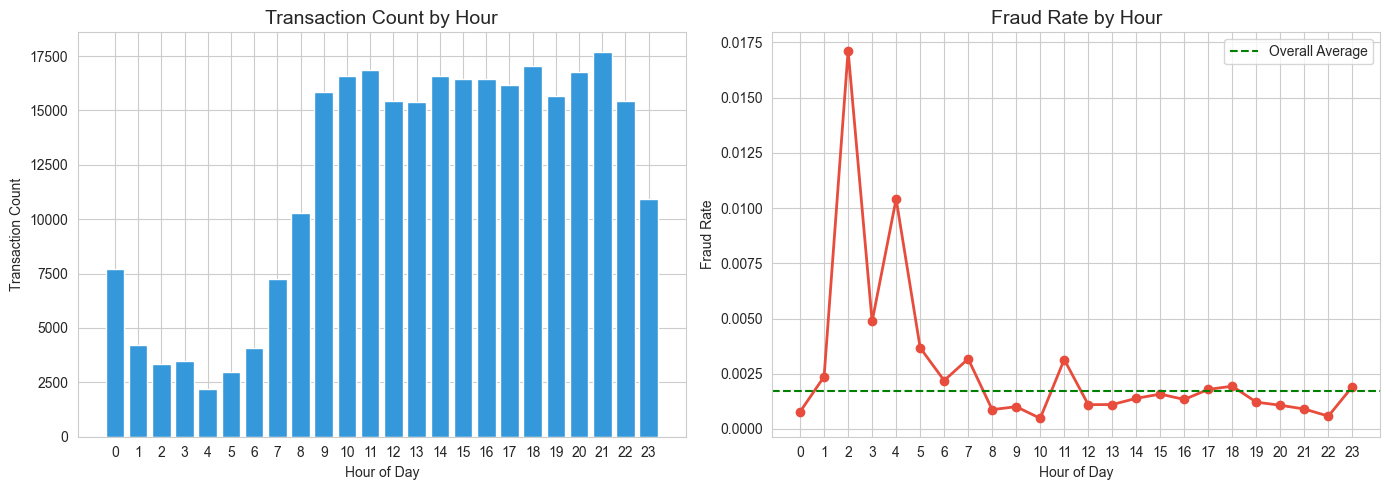

✓ Chart saved to docs/images/time_analysis.png


In [18]:
# Visualize fraud rate by hour
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction count by hour
hourly_counts = df.groupby('hour').size()
axes[0].bar(hourly_counts.index, hourly_counts.values, color='#3498db')
axes[0].set_title('Transaction Count by Hour', fontsize=14)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Transaction Count')
axes[0].set_xticks(range(24))

# Fraud rate by hour
axes[1].plot(hourly_fraud_rate.index, hourly_fraud_rate.values, marker='o', color='#e74c3c', linewidth=2)
axes[1].set_title('Fraud Rate by Hour', fontsize=14)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_xticks(range(24))
axes[1].axhline(y=df['class'].mean(), color='green', linestyle='--', label='Overall Average')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/images/time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart saved to docs/images/time_analysis.png")

## 7. Correlation Analysis (V Features)

In [19]:
# Select V features for correlation
v_features = [col for col in df.columns if col.startswith('v')]

# Calculate correlation matrix
correlation_matrix = df[v_features].corr()

print("=== Correlation Matrix Statistics ===")
print(f"Mean absolute correlation: {correlation_matrix.abs().mean().mean():.4f}")
print(f"Max correlation: {correlation_matrix.abs().max().max():.4f}")

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(v_features)):
    for j in range(i+1, len(v_features)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.9:
            high_corr_pairs.append((v_features[i], v_features[j], corr_val))

print(f"\n=== Highly Correlated Pairs (|r| > 0.9): {len(high_corr_pairs)} pairs ===")
for pair in high_corr_pairs[:10]:  # Show first 10
    print(f"  {pair[0]} <-> {pair[1]}: {pair[2]:.4f}")

=== Correlation Matrix Statistics ===
Mean absolute correlation: 0.0357
Max correlation: 1.0000

=== Highly Correlated Pairs (|r| > 0.9): 0 pairs ===


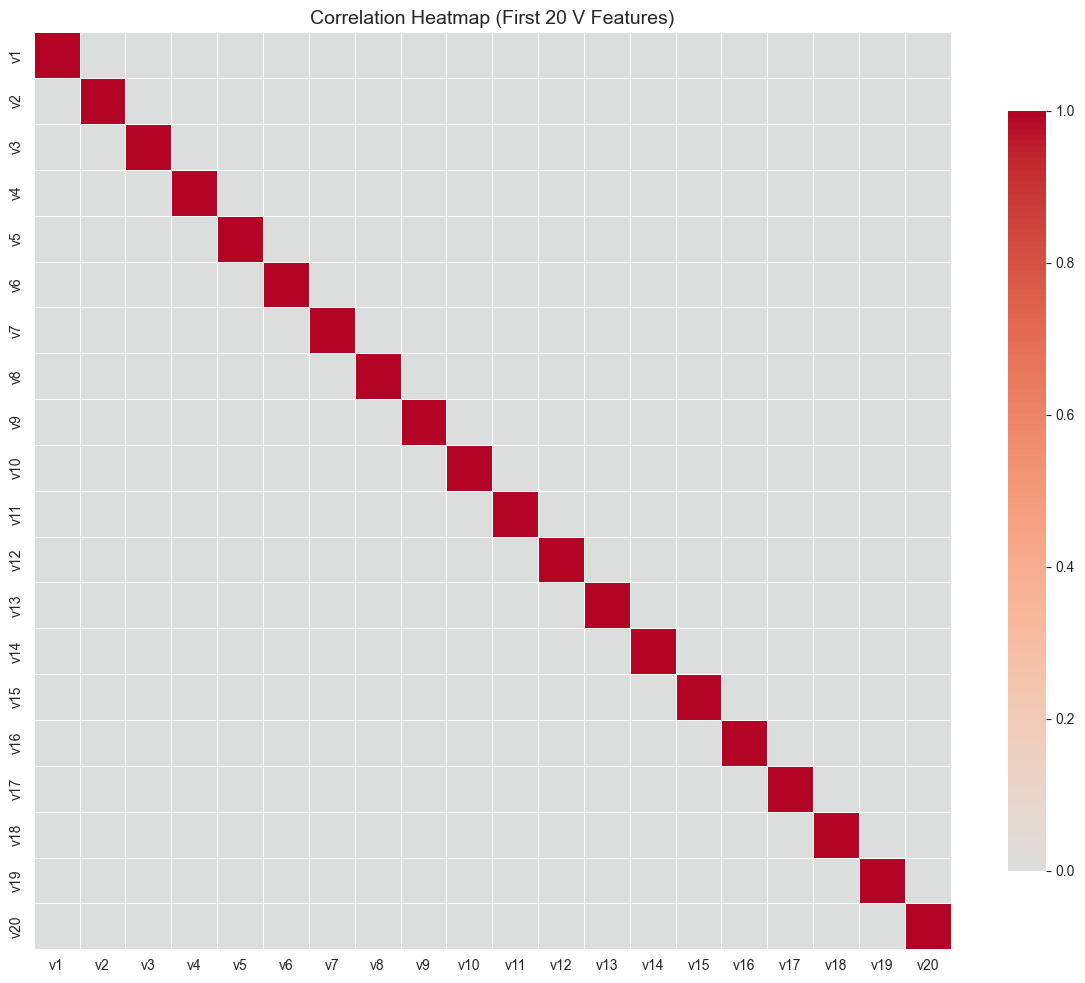

✓ Chart saved to docs/images/correlation_heatmap.png


In [20]:
# Correlation heatmap (subset of features)
fig, ax = plt.subplots(figsize=(12, 10))

# Select first 20 V features for readability
v_subset = v_features[:20]
sns.heatmap(df[v_subset].corr(), cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Heatmap (First 20 V Features)', fontsize=14)

plt.tight_layout()
plt.savefig('../docs/images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart saved to docs/images/correlation_heatmap.png")

## 8. Summary Report

In [21]:
print("="*60)
print("           EDA SUMMARY REPORT")
print("       Credit Card Fraud Detection Dataset")
print("="*60)

print("\n📊 DATASET OVERVIEW")
print(f"   Total Transactions: {len(df):,}")
print(f"   Features: {df.shape[1]-1} (excluding target)")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n⚖️ CLASS IMBALANCE")
legit_count = class_counts[0]
fraud_count = class_counts[1]
imbalance_ratio = legit_count / fraud_count
print(f"   Legitimate: {legit_count:,} ({class_percentages[0]:.4f}%)")
print(f"   Fraud: {fraud_count:,} ({class_percentages[1]:.4f}%)")
print(f"   Imbalance Ratio: {imbalance_ratio}:1")
print(f"   ⚠️  Severe imbalance detected - requires special handling")

print("\n💰 TRANSACTION AMOUNT")
legit_mean = df[df['class']==0]['amount'].mean()
fraud_mean = df[df['class']==1]['amount'].mean()
print(f"   Legitimate Mean: ${legit_mean:.2f}")
print(f"   Fraud Mean: ${fraud_mean:.2f}")
print(f"   Fraud transactions are {'higher' if fraud_mean > legit_mean else 'lower'} on average")

print("\n🕐 TIME PATTERNS")
max_fraud_hour = hourly_fraud_rate.idxmax()
min_fraud_hour = hourly_fraud_rate.idxmin()
print(f"   Peak Fraud Hour: {max_fraud_hour}:00 (rate: {hourly_fraud_rate[max_fraud_hour]:.4%})")
print(f"   Lowest Fraud Hour: {min_fraud_hour}:00 (rate: {hourly_fraud_rate[min_fraud_hour]:.4%})")

print("\n📈 FEATURES")
print(f"   V1-V28: PCA-transformed, anonymized features")
print(f"   Time: Seconds since first transaction")
print(f"   Amount: Transaction amount in USD")

print("\n🔑 KEY INSIGHTS")
print("   1. Severe class imbalance - use class_weight='balanced'")
print("   2. V features are already PCA-transformed (no scaling needed)")
print("   3. Time-based patterns exist - consider hour-of-day feature")
print("   4. Amount differs between classes - informative feature")

print("\n✓ Report complete! Charts saved to docs/images/")
print("="*60)

           EDA SUMMARY REPORT
       Credit Card Fraud Detection Dataset

📊 DATASET OVERVIEW
   Total Transactions: 284,807
   Features: 33 (excluding target)
   Memory: 73.88 MB

⚖️ CLASS IMBALANCE
   Legitimate: 284,315 (99.8273%)
   Fraud: 492 (0.1727%)
   Imbalance Ratio: 577.8760162601626:1
   ⚠️  Severe imbalance detected - requires special handling

💰 TRANSACTION AMOUNT
   Legitimate Mean: $88.29
   Fraud Mean: $122.21
   Fraud transactions are higher on average

🕐 TIME PATTERNS
   Peak Fraud Hour: 2:00 (rate: 1.7127%)
   Lowest Fraud Hour: 10:00 (rate: 0.0482%)

📈 FEATURES
   V1-V28: PCA-transformed, anonymized features
   Time: Seconds since first transaction
   Amount: Transaction amount in USD

🔑 KEY INSIGHTS
   1. Severe class imbalance - use class_weight='balanced'
   2. V features are already PCA-transformed (no scaling needed)
   3. Time-based patterns exist - consider hour-of-day feature
   4. Amount differs between classes - informative feature

✓ Report complete! Char